# 📈 DS5044 – Análisis de Series de Tiempo
## 🎓 Proyecto de Medio Curso: Modelamiento y Forecasting de Series de Tiempo Reales del Perú
* **Institución:** Universidad de Ingeniería y Tecnología (UTEC)
* **Departamento:** Ciencia de Datos
* **Docente:** D.Sc. Yván Jesús Túpac Valdivia
* **Periodo Académico:** 2026-2

---

### 📝 Instrucciones de Entrega
1. Este cuaderno de Google Colab debe ejecutarse completamente de principio a fin sin generar errores de ejecución.
2. Cada grupo (máximo 2 integrantes) completará los bloques de código marcado con `# TODO (Alumno)` y responderá a las preguntas de análisis técnico en las celdas de Markdown asignadas.
3. El archivo `.ipynb` descargado o link al cuaderno COLAB y el Informe Técnico en PDF deben subirse a la plataforma Canvas en la tarea correspondiente.

In [1]:
# ==============================================================================
# CONFIGURACIÓN DEL ENTORNO E INSTALACIÓN DE LIBRERÍAS
# ==============================================================================
!pip install statsmodels scipy matplotlib seaborn pmdarima yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Herramientas de Time Series
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# Configuración de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.8 MB/s eta 0:00:00


## 🌐 1. Carga de Datos y Definición de Series (Perú)
Seleccionen dos series de datos reales del Perú (fuentes sugeridas: BCRPData, COES, BVL, INEI, Datos Abiertos):
* **Serie A (Macroeconómica / Con Estacionalidad):** Ej. PBI Mensual, Inflación, Demanda Eléctrica COES, Turistas.
* **Serie B (Financiera / Transaccional):** Ej. Tipo de Cambio USD/PEN, Retornos BVL, Precio de Exportaciones.

In [2]:
# ==============================================================================
# 1. CARGA DE DATOS
# Serie B (Financiera): Tipo de cambio Yen por USD (¥/USD), promedio mensual
# Fuente: BCRPData, código PN01224XM  |  Ago-2006 a Ago-2026
# ==============================================================================
import os, requests

MESES = {'Ene':1,'Feb':2,'Mar':3,'Abr':4,'May':5,'Jun':6,'Jul':7,
         'Ago':8,'Sep':9,'Set':9,'Oct':10,'Nov':11,'Dic':12}

def parse_periodo(p):
    """Convierte 'Ago06', 'Ago.2006' o 'Ago.06' -> Timestamp (primer día del mes)."""
    p = str(p).replace('.', '').strip()
    mes, anio = MESES[p[:3].capitalize()], int(p[3:])
    if anio < 100:
        anio += 2000
    return pd.Timestamp(anio, mes, 1)

def cargar_bcrp(codigo, inicio, fin, archivo_local=None, nombre='valor'):
    """1) Intenta descargar desde la API de BCRPData.
       2) Si falla, usa el CSV exportado desde BCRPData (ruta local o URL raw de GitHub)."""
    url = f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/{codigo}/json/{inicio}/{fin}"
    try:
        r = requests.get(url, timeout=30, headers={'User-Agent': 'Mozilla/5.0'})
        r.raise_for_status()
        periodos = r.json()['periods']
        fechas  = [parse_periodo(x['name']) for x in periodos]
        valores = [pd.to_numeric(x['values'][0], errors='coerce') for x in periodos]
        s = pd.Series(valores, index=fechas, name=nombre)
        print(f"✔ {codigo}: descargada desde API BCRP")
    except Exception as e:
        print(f"⚠ API BCRP no disponible ({type(e).__name__}); usando archivo: {archivo_local}")
        df = pd.read_csv(archivo_local, skiprows=2, header=None,
                         names=['periodo', 'valor'], encoding='latin-1')
        s = pd.Series(pd.to_numeric(df['valor'], errors='coerce').values,
                      index=df['periodo'].map(parse_periodo), name=nombre)
    s.index = pd.DatetimeIndex(s.index)
    s = s.sort_index().asfreq('MS')          # frecuencia mensual explícita
    if s.isna().any():                        # por si hay 'n.d.'
        s = s.interpolate()
    return s

serie_B = cargar_bcrp('PN01224XM', '2006-8', '2026-8',
                      archivo_local='Mensuales-20260924-163355.csv',
                      nombre='JPY por USD')

print(f"Observaciones: {len(serie_B)} | Desde {serie_B.index[0]:%Y-%m} hasta {serie_B.index[-1]:%Y-%m}")
print(serie_B.describe().round(3))
print("Series cargadas exitosamente.")

✔ PN01224XM: descargada desde API BCRP
Observaciones: 241 | Desde 2006-08 hasta 2026-08
count    241.000
mean     113.105
std       21.779
min       76.684
25%      100.334
50%      109.853
75%      120.847
max      162.270
Name: JPY por USD, dtype: float64
Series cargadas exitosamente.


## 🔍 2. PARTE I: Análisis Exploratorio, Componentes y Estacionariedad

### 2.1 Visualización y Descomposición STL
Grafiquen ambas series y apliquen la descomposición STL para aislar la tendencia, estacionalidad y residuo.

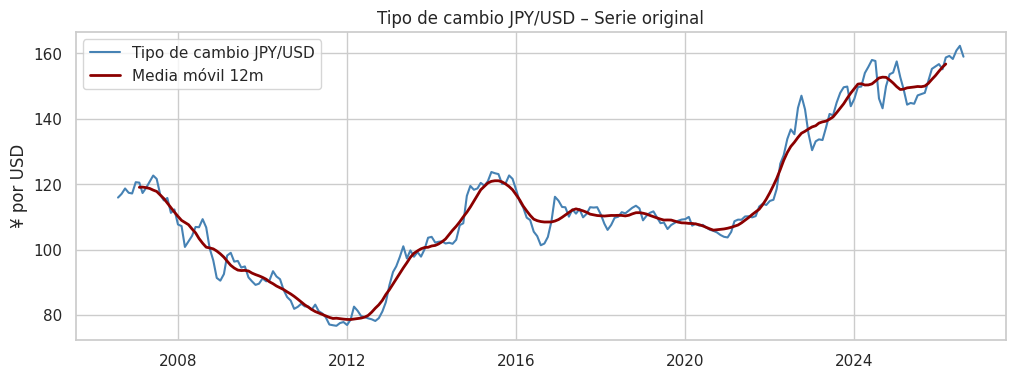

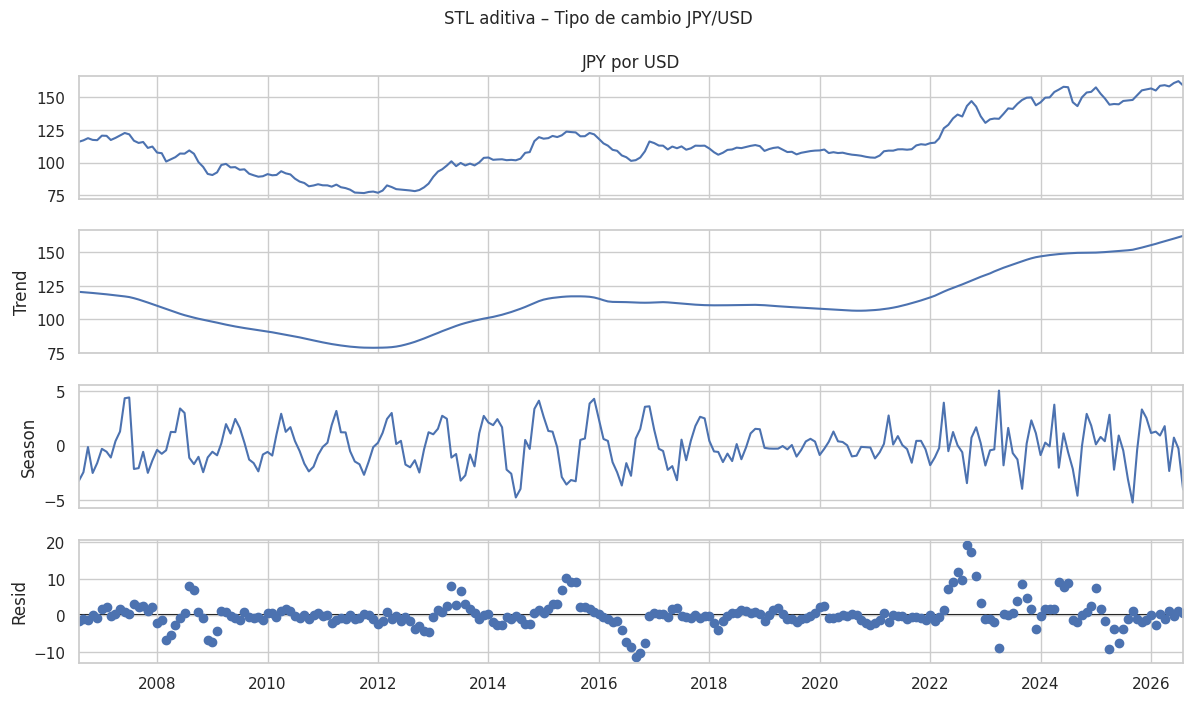

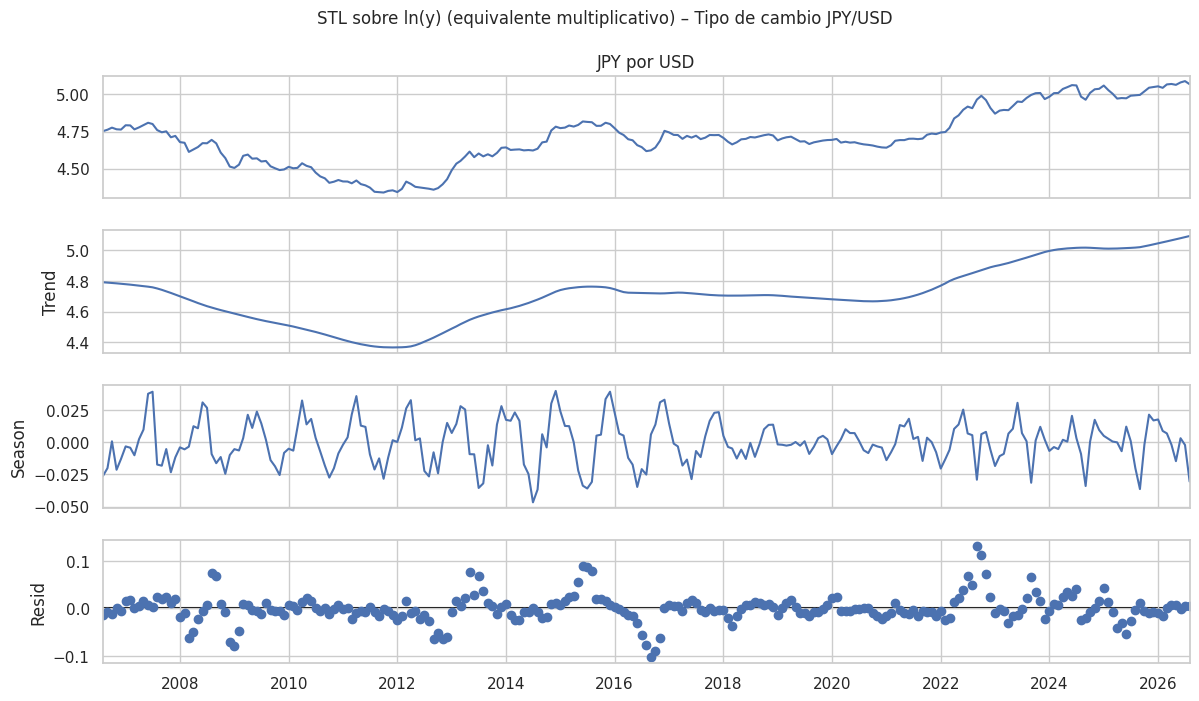

Fuerza de Tendencia     F_T = 0.976
Fuerza de Estacionalidad F_S = 0.172  (F_S < 0.4 => estacionalidad débil)


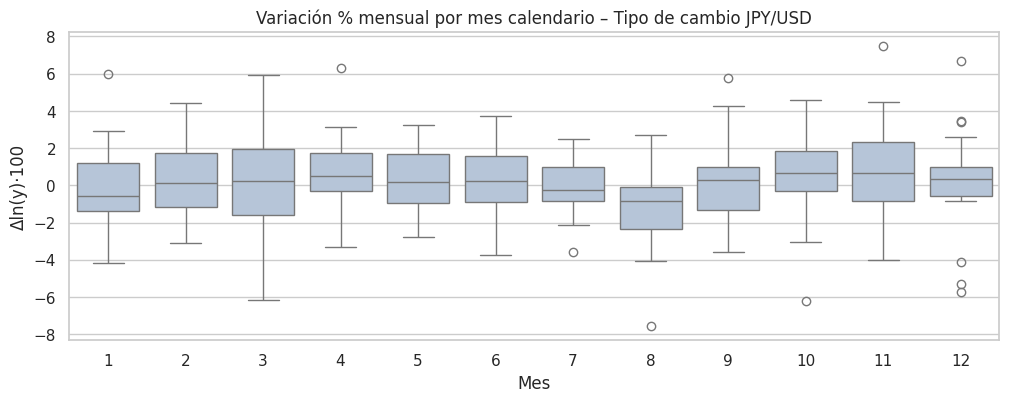


Observaciones atípicas (|z| > 3 en residuo STL):
2016-09-01   -3.48
2016-10-01   -3.06
2022-09-01    4.46
2022-10-01    3.80
Name: resid, dtype: float64


In [3]:
# ==============================================================================
# 2.1 VISUALIZACIÓN Y DESCOMPOSICIÓN (STL aditiva / multiplicativa)
# ==============================================================================
def analisis_exploratorio(serie, nombre, periodo=12, unidad=''):
    # --- (a) Serie original + media móvil 12m ---
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(serie, label=nombre, color='steelblue')
    ax.plot(serie.rolling(periodo, center=True).mean(), label=f'Media móvil {periodo}m',
            color='darkred', lw=2)
    ax.set_title(f'{nombre} – Serie original'); ax.set_ylabel(unidad); ax.legend()
    plt.show()

    # --- (b) STL aditiva sobre la serie en niveles ---
    stl_add = STL(serie, period=periodo, robust=True).fit()
    fig = stl_add.plot(); fig.set_size_inches(12, 7)
    fig.suptitle(f'STL aditiva – {nombre}', y=1.02); plt.show()

    # --- (c) STL "multiplicativa": STL sobre ln(serie) -> y = T·S·R ---
    stl_mul = STL(np.log(serie), period=periodo, robust=True).fit()
    fig = stl_mul.plot(); fig.set_size_inches(12, 7)
    fig.suptitle(f'STL sobre ln(y) (equivalente multiplicativo) – {nombre}', y=1.02); plt.show()

    # --- (d) Fuerza de tendencia y estacionalidad (Hyndman & Athanasopoulos, 2021) ---
    T, S, R = stl_mul.trend, stl_mul.seasonal, stl_mul.resid
    F_T = max(0, 1 - np.var(R) / np.var(T + R))
    F_S = max(0, 1 - np.var(R) / np.var(S + R))
    print(f"Fuerza de Tendencia     F_T = {F_T:.3f}")
    print(f"Fuerza de Estacionalidad F_S = {F_S:.3f}  (F_S < 0.4 => estacionalidad débil)")

    # --- (e) Boxplot mensual para inspeccionar estacionalidad ---
    dlog = np.log(serie).diff().dropna() * 100
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.boxplot(x=dlog.index.month, y=dlog.values, ax=ax, color='lightsteelblue')
    ax.set_title(f'Variación % mensual por mes calendario – {nombre}')
    ax.set_xlabel('Mes'); ax.set_ylabel('Δln(y)·100'); plt.show()

    # --- (f) Atípicos: residuos STL robustos con |z| > 3 ---
    z = (R - R.mean()) / R.std()
    atipicos = z[np.abs(z) > 3]
    print("\nObservaciones atípicas (|z| > 3 en residuo STL):")
    print(atipicos.round(2) if len(atipicos) else "Ninguna")
    return stl_mul

stl_B = analisis_exploratorio(serie_B, 'Tipo de cambio JPY/USD', unidad='¥ por USD')

### 🧠 Pregunta 1.1:
> Describan las componentes identificadas en la Serie A y Serie B (Tendencia, Estacionalidad, Ciclo). ¿Existen quiebres estructurales u observaciones atípicas? Justifiquen su respuesta.  

Tendencia: muy fuerte, con F_T = 0.976.  
Estacionalidad: débil,con F_S = 0.172 < 0.4. Esto es lo esperable en un tipo de cambio.  
Ciclo: se ven fases largas, apreciación del yen entre 2007 y 2012, con un mínimo de 77 ¥/USD;
luego vino la depreciación desde 2013 (Abenomics) causas políticas de Japón;
relativa estabilidad entre 2016 y 2021 con un cambio claro y poco duradero por la pandemia;
fuerte depreciación desde 2022 por el diferencial de tasas Fed–BoJ, hasta máximos de ≈162.  
Quiebres estructurales: hay quiebres plausibles en 2013 y en 2022.
Atípicos: el residuo STL marca atípicos en sep–oct 2016 y sep–oct 2022. Los de 2022 coinciden con las intervenciones cambiarias de Japón.

### 2.2 Diagnóstico de Estacionariedad y Firma Autocorrelativa (FAC / FACP)
Evalúen las funciones de autocorrelación y apliquen la prueba formal de **Dickey-Fuller Aumentada (ADF)**.

--- Prueba ADF: JPY/USD | y (nivel) ---
Estadístico ADF: -0.4378
p-value: 9.0359e-01
Valores críticos: 1%: -3.458, 5%: -2.874, 10%: -2.573
Resultado: La serie NO es Estacionaria (No rechaza H0)

--- Prueba ADF: JPY/USD | ln(y) ---
Estadístico ADF: -0.6067
p-value: 8.6946e-01
Valores críticos: 1%: -3.458, 5%: -2.874, 10%: -2.573
Resultado: La serie NO es Estacionaria (No rechaza H0)

--- Prueba ADF: JPY/USD | ∇ ln(y) ---
Estadístico ADF: -11.3921
p-value: 8.0207e-21
Valores críticos: 1%: -3.458, 5%: -2.874, 10%: -2.573
Resultado: La serie ES Estacionaria (Rechaza H0)

--- Prueba ADF: JPY/USD | ∇_12 ln(y) ---
Estadístico ADF: -1.9029
p-value: 3.3072e-01
Valores críticos: 1%: -3.461, 5%: -2.875, 10%: -2.574
Resultado: La serie NO es Estacionaria (No rechaza H0)

--- Prueba ADF: JPY/USD | ∇∇_12 ln(y) ---
Estadístico ADF: -7.1274
p-value: 3.5906e-10
Valores críticos: 1%: -3.461, 5%: -2.875, 10%: -2.574
Resultado: La serie ES Estacionaria (Rechaza H0)



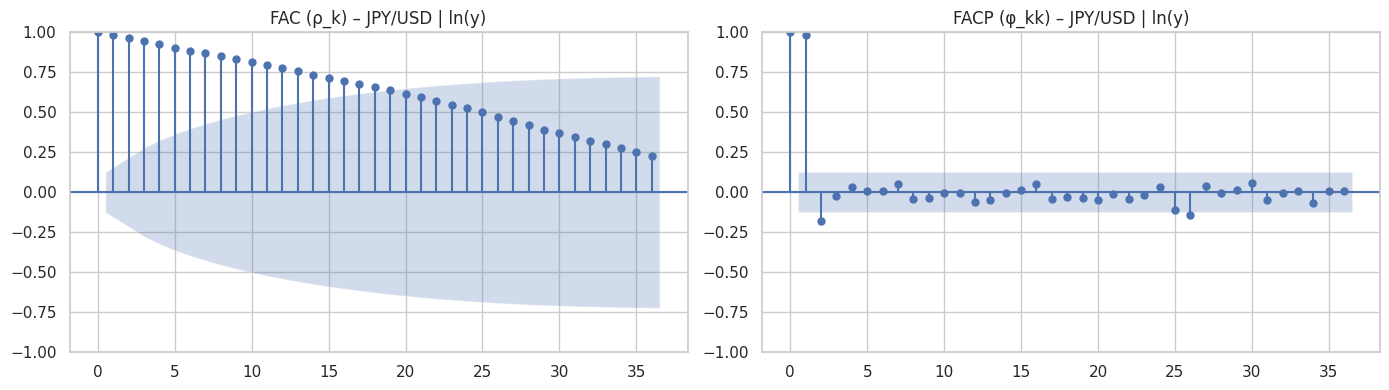

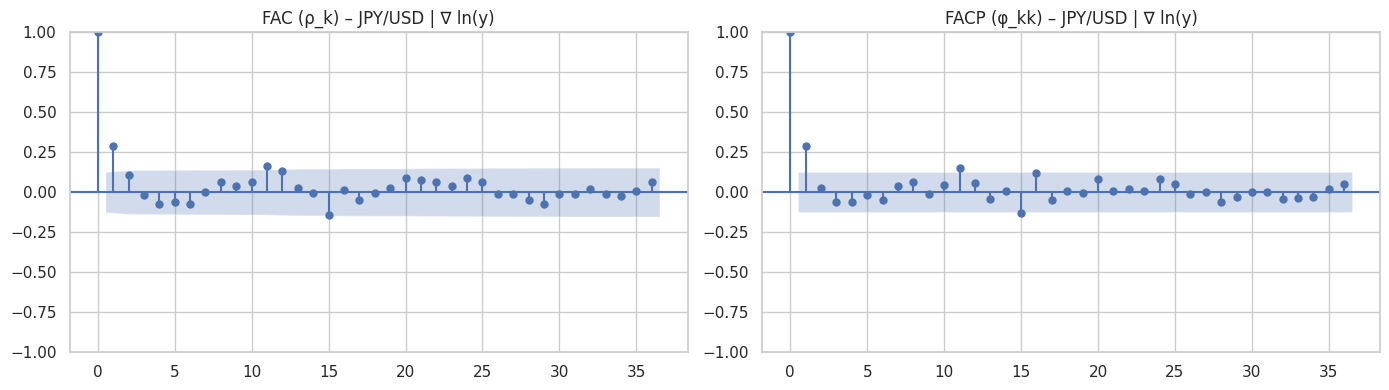

,ADF,p-value,Estacionaria
Serie,,,
JPY/USD | y (nivel),-0.4378,0.9036,False
JPY/USD | ln(y),-0.6067,0.8695,False
JPY/USD | ∇ ln(y),-11.3921,0.0000,True
JPY/USD | ∇_12 ln(y),-1.9029,0.3307,False
JPY/USD | ∇∇_12 ln(y),-7.1274,0.0000,True


In [4]:
# ==============================================================================
# 2.2 DIAGNÓSTICO DE ESTACIONARIEDAD: ADF + FAC / FACP
# ==============================================================================
def evaluar_estacionariedad(serie, nombre="Serie", verbose=True):
    result = adfuller(serie.dropna(), autolag='AIC')
    if verbose:
        print(f"--- Prueba ADF: {nombre} ---")
        print(f"Estadístico ADF: {result[0]:.4f}")
        print(f"p-value: {result[1]:.4e}")
        print(f"Valores críticos: " + ", ".join(f"{k}: {v:.3f}" for k, v in result[4].items()))
        if result[1] < 0.05:
            print("Resultado: La serie ES Estacionaria (Rechaza H0)\n")
        else:
            print("Resultado: La serie NO es Estacionaria (No rechaza H0)\n")
    return {'Serie': nombre, 'ADF': result[0], 'p-value': result[1],
            'Estacionaria': result[1] < 0.05}

def graficar_fac_facp(serie, nombre, lags=36):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(serie.dropna(), lags=lags, ax=ax[0], title=f'FAC (ρ_k) – {nombre}')
    plot_pacf(serie.dropna(), lags=lags, ax=ax[1], method='ywm', title=f'FACP (φ_kk) – {nombre}')
    plt.tight_layout(); plt.show()

def diagnostico_completo(serie, nombre, s=12):
    y_log = np.log(serie)                       # estabiliza varianza
    transformaciones = {
        'y (nivel)':        serie,
        'ln(y)':            y_log,
        '∇ ln(y)':          y_log.diff(),
        '∇_12 ln(y)':       y_log.diff(s),
        '∇∇_12 ln(y)':      y_log.diff().diff(s),
    }
    tabla = []
    for k, v in transformaciones.items():
        tabla.append(evaluar_estacionariedad(v, f'{nombre} | {k}'))
    for k in ['ln(y)', '∇ ln(y)']:
        graficar_fac_facp(transformaciones[k], f'{nombre} | {k}')
    df = pd.DataFrame(tabla).set_index('Serie')
    display(df.round(4))
    return df

adf_B = diagnostico_completo(serie_B, 'JPY/USD')

# Serie estacionaria elegida para Serie B: ∇ ln(y)  ->  d = 1, D = 0
serie_B_log = np.log(serie_B)
serie_B_est = serie_B_log.diff().dropna()

### 🧠 Pregunta 1.2:
> Analicen el comportamiento de la FAC ($\rho_k$) y FACP ($\phi_{kk}$). Indiquen qué grado de diferenciaciones regulares ($d$) o estacionales ($D$) requirió cada serie para volverse estacionaria.  

Serie sin diferenciar: la FAC de ln(y) decae muy lentamente, lo que indica una raíz unitaria. La ADF no rechaza H0 (p = 0.87).  

Primera diferencia: con ∇ln(y), la ADF da −11.39 (p ≈ 0), así que la serie es estacionaria.  

Firma autocorrelativa: ρ₁ ≈ 0.29 y φ₁₁ ≈ 0.29, y luego ambas funciones caen dentro de las bandas. Solo aparece un pico marginal en el rezago 12 (≈0.16).  

Esto sugiere un AR(1) o MA(1).  

Diferenciación estacional: ∇₁₂ sola no logra tener estacionariedad (p = 0.33). ∇∇₁₂ sí, pero sería sobrediferenciar.  

Por lo que llegamos a d = 1, D = 0.

## 📊 3. PARTE II: Modelos Benchmark y Suavizado Exponencial

Dividan los datos en **Train (80%)** y **Test (20%)** para validación fuera de muestra (*Out-of-Sample*).

Train: 2006-08 a 2022-07 (192 obs)
Test : 2022-08 a 2026-08 (49 obs)

Parámetros de suavizado – JPY/USD


,α,β,γ,φ,AIC,AICc,BIC,SSE
Modelo,,,,,,,,
SES,1.0,NaN,NaN,NaN,328.3797,328.5936,334.8947,1039.9969
Holt lineal,1.0,0.1126,NaN,NaN,326.4561,326.9102,339.4861,1008.4008
Holt amortiguado,1.0,0.3112,NaN,0.8,317.5209,318.1296,333.8084,952.5730
Holt-Winters Aditivo,1.0,0.3168,0.0,0.8,330.5852,335.0038,385.9626,899.8337
Holt-Winters Multiplicativo,1.0,0.3190,0.0,0.8,330.0698,334.4884,385.4473,897.4216


Métricas Out-of-Sample – JPY/USD


,MAE,RMSE,MAPE (%)
Naïve,12.549,14.265,8.234
Promedio Global,44.411,45.137,29.697
Naïve Estacional,29.102,31.111,19.407
SES,12.549,14.265,8.234
Holt lineal,43.173,49.846,28.586
Holt amortiguado,6.350,7.707,4.251
Holt-Winters Aditivo,6.544,7.786,4.380
Holt-Winters Multiplicativo,6.721,7.936,4.489


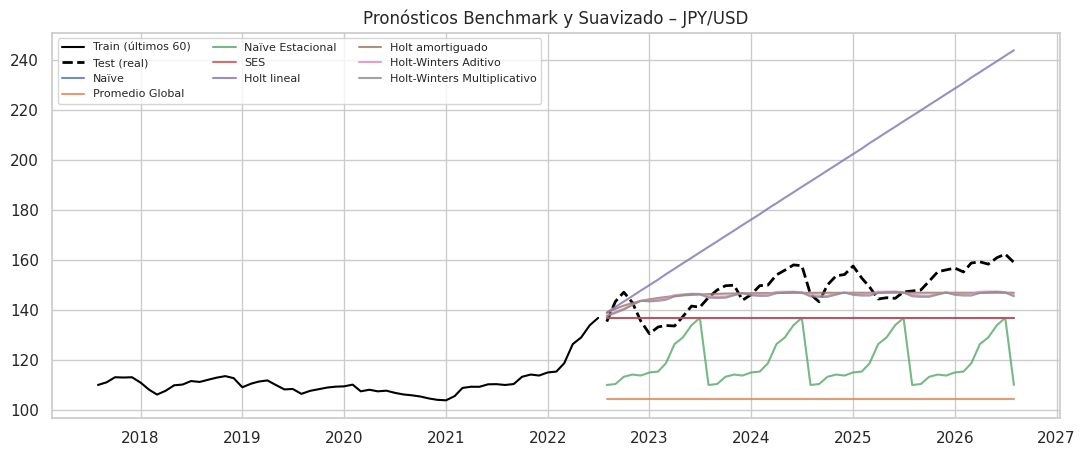

In [5]:
# ==============================================================================
# 3. PARTICIÓN TRAIN (80%) / TEST (20%) + BENCHMARKS + SUAVIZADO EXPONENCIAL
# ==============================================================================
def calcular_metricas(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

def particion(serie, frac=0.8):
    corte = int(len(serie) * frac)
    return serie.iloc[:corte], serie.iloc[corte:]

def modelos_benchmark_suavizado(train, test, s=12, nombre='Serie'):
    h = len(test); idx = test.index
    pred, info = {}, {}

    # ---------- Benchmarks ----------
    pred['Naïve']            = pd.Series(train.iloc[-1], index=idx)
    pred['Promedio Global']  = pd.Series(train.mean(), index=idx)
    pred['Naïve Estacional'] = pd.Series([train.iloc[-s + (i % s)] for i in range(h)], index=idx)

    # ---------- Suavizado exponencial ----------
    m = SimpleExpSmoothing(train, initialization_method='estimated').fit()
    pred['SES'] = m.forecast(h); info['SES'] = m

    m = Holt(train, initialization_method='estimated').fit()
    pred['Holt lineal'] = m.forecast(h); info['Holt lineal'] = m

    m = Holt(train, damped_trend=True, initialization_method='estimated').fit()
    pred['Holt amortiguado'] = m.forecast(h); info['Holt amortiguado'] = m

    for tipo, lab in [('add', 'Aditivo'), ('mul', 'Multiplicativo')]:
        m = ExponentialSmoothing(train, trend='add', damped_trend=True, seasonal=tipo,
                                 seasonal_periods=s, initialization_method='estimated').fit()
        pred[f'Holt-Winters {lab}'] = m.forecast(h); info[f'Holt-Winters {lab}'] = m

    # ---------- Parámetros e información ----------
    filas = []
    for k, m in info.items():
        p = m.params
        filas.append({'Modelo': k, 'α': p.get('smoothing_level'), 'β': p.get('smoothing_trend'),
                      'γ': p.get('smoothing_seasonal'), 'φ': p.get('damping_trend'),
                      'AIC': m.aic, 'AICc': m.aicc, 'BIC': m.bic, 'SSE': m.sse})
    print(f"Parámetros de suavizado – {nombre}")
    display(pd.DataFrame(filas).set_index('Modelo').round(4))

    # ---------- Métricas fuera de muestra ----------
    met = pd.DataFrame({k: calcular_metricas(test, v) for k, v in pred.items()}).T
    print(f"Métricas Out-of-Sample – {nombre}")
    display(met.round(3))

    # ---------- Gráfico ----------
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train.iloc[-60:], color='black', label='Train (últimos 60)')
    ax.plot(test, color='black', ls='--', lw=2, label='Test (real)')
    for k, v in pred.items():
        ax.plot(v, label=k, alpha=0.8)
    ax.set_title(f'Pronósticos Benchmark y Suavizado – {nombre}')
    ax.legend(ncol=3, fontsize=8); plt.show()
    return pred, met

train_B, test_B = particion(serie_B)
print(f"Train: {train_B.index[0]:%Y-%m} a {train_B.index[-1]:%Y-%m} ({len(train_B)} obs)")
print(f"Test : {test_B.index[0]:%Y-%m} a {test_B.index[-1]:%Y-%m} ({len(test_B)} obs)\n")

pred_B, met_suav_B = modelos_benchmark_suavizado(train_B, test_B, nombre='JPY/USD')

### 🧠 Pregunta 2.1:
> Compare los métodos de suavizado. ¿Se justificó el uso de Holt-Winters (aditivo o multiplicativo) frente al suavizado simple en la Serie A? Fundamente numéricamente.  


SES: estima α = 1, así que se reduce exactamente al Naive. Tiene la misma métrica RMSE= 14.27, porque la serie se comporta como una caminata aleatoria.  

Holt-Winters: estima γ = 0, es decir, la estacionalidad no se actualiza. Además, su AICc ≈335 es peor que el de Holt amortiguado ≈318.  

Holt amortiguado: es el mejor del grupo fuera de muestra RMSE =7.71.  

El YEN no se justifica Holt-Winters. Su buen desempeño viene de la tendencia amortiguada, no del componente estacional.

## ⚙️ 4. PARTE III: Metodología Box-Jenkins (AR, MA, ARMA, ARIMA, SARIMA)

### 4.1 Grid de Búsqueda y Criterios de Información ($AIC, AIC_c, BIC$)
Implementen un *grid* de modelos candidatos y seleccionen el modelo óptimo sustentado en el **Principio de Parsimonia**.

In [6]:
# ==============================================================================
# 4.1 GRID DE BÚSQUEDA ARIMA / SARIMA (sobre ln(y), d y D fijados por ADF)
# ==============================================================================
import itertools
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

def grid_sarima(train_log, d, D, s=12, p_max=3, q_max=3, P_max=1, Q_max=1):
    results_grid = []
    for p, q, P, Q in itertools.product(range(p_max+1), range(q_max+1),
                                        range(P_max+1), range(Q_max+1)):
        order, seasonal_order = (p, d, q), (P, D, Q, s)
        try:
            model = ARIMA(train_log, order=order, seasonal_order=seasonal_order).fit()
            results_grid.append({'order (p,d,q)': order, 'seasonal (P,D,Q,s)': seasonal_order,
                                 'k (parámetros)': len(model.params),
                                 'AIC': model.aic, 'AICc': model.aicc, 'BIC': model.bic})
        except Exception as e:
            print(f"Falló {order}x{seasonal_order}: {e}")
    df_grid = pd.DataFrame(results_grid)
    for c in ['AIC', 'AICc', 'BIC']:
        df_grid[f'Δ{c}'] = df_grid[c] - df_grid[c].min()
    return df_grid.sort_values(by='BIC').reset_index(drop=True)

train_B_log = np.log(train_B)
df_grid_B = grid_sarima(train_B_log, d=1, D=0)
print("Top 10 modelos por BIC – JPY/USD (sobre ln y)")
display(df_grid_B.head(10).round(3))
print("\nTop 5 por AICc:")
display(df_grid_B.sort_values('AICc').head(5).round(3))

# ---- Selección por parsimonia: menor BIC; ante ΔAICc < 2 se prefiere el de menos parámetros ----
orden_B, orden_est_B = (1, 1, 0), (0, 0, 0, 12)
model_opt_B = ARIMA(train_B_log, order=orden_B, seasonal_order=orden_est_B).fit()
print(model_opt_B.summary())

Top 10 modelos por BIC – JPY/USD (sobre ln y)


,"order (p,d,q)","seasonal (P,D,Q,s)",k (parámetros),AIC,AICc,BIC,ΔAIC,ΔAICc,ΔBIC
0,"(1, 1, 0)","(0, 0, 0, 12)",2,-925.441,-925.377,-918.937,2.345,2.281,0.000
1,"(0, 1, 2)","(0, 0, 0, 12)",3,-927.787,-927.658,-918.030,0.000,0.000,0.907
2,"(2, 1, 0)","(0, 0, 0, 12)",3,-926.573,-926.444,-916.816,1.214,1.214,2.121
3,"(1, 1, 0)","(1, 0, 0, 12)",3,-925.249,-925.121,-915.493,2.537,2.537,3.444
4,"(1, 1, 1)","(0, 0, 0, 12)",3,-925.225,-925.096,-915.468,2.562,2.562,3.469
5,"(1, 1, 0)","(0, 0, 1, 12)",3,-925.168,-925.040,-915.411,2.619,2.619,3.525
6,"(0, 1, 1)","(0, 0, 0, 12)",2,-920.441,-920.377,-913.936,7.346,7.281,5.000
7,"(0, 1, 2)","(1, 0, 0, 12)",4,-926.895,-926.680,-913.886,0.892,0.979,5.051
8,"(0, 1, 2)","(0, 0, 1, 12)",4,-926.844,-926.629,-913.835,0.943,1.030,5.102
9,"(2, 1, 0)","(1, 0, 0, 12)",4,-926.185,-925.970,-913.176,1.601,1.688,5.761



Top 5 por AICc:


,"order (p,d,q)","seasonal (P,D,Q,s)",k (parámetros),AIC,AICc,BIC,ΔAIC,ΔAICc,ΔBIC
1,"(0, 1, 2)","(0, 0, 0, 12)",3,-927.787,-927.658,-918.030,0.000,0.000,0.907
7,"(0, 1, 2)","(1, 0, 0, 12)",4,-926.895,-926.680,-913.886,0.892,0.979,5.051
8,"(0, 1, 2)","(0, 0, 1, 12)",4,-926.844,-926.629,-913.835,0.943,1.030,5.102
2,"(2, 1, 0)","(0, 0, 0, 12)",3,-926.573,-926.444,-916.816,1.214,1.214,2.121
9,"(2, 1, 0)","(1, 0, 0, 12)",4,-926.185,-925.970,-913.176,1.601,1.688,5.761


                               SARIMAX Results                                
Dep. Variable:            JPY por USD   No. Observations:                  192
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 464.721
Date:                Fri, 25 Sep 2026   AIC                           -925.441
Time:                        17:15:27   BIC                           -918.937
Sample:                    08-01-2006   HQIC                          -922.807
                         - 07-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3097      0.066      4.697      0.000       0.180       0.439
sigma2         0.0005   4.25e-05     10.606      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   0.31   Jarque-

### 4.2 Verificación Teórica: Causalidad e Invertibilidad (Raíces en $|z| > 1$)
Verifiquen que todas las raíces de $\phi(z)=0$ y $\theta(z)=0$ se ubiquen estrictamente fuera del círculo unitario ($|z_i| > 1$).

=== ARIMA(1, 1, 0) – JPY/USD ===
φ(z) coef.: [ 1.     -0.3097]
θ(z) coef.: [1.]
Raíces AR: [3.2289] | |z| = [3.2289] -> Causal: True
Raíces MA: no hay (polinomio = 1) -> Invertible trivialmente


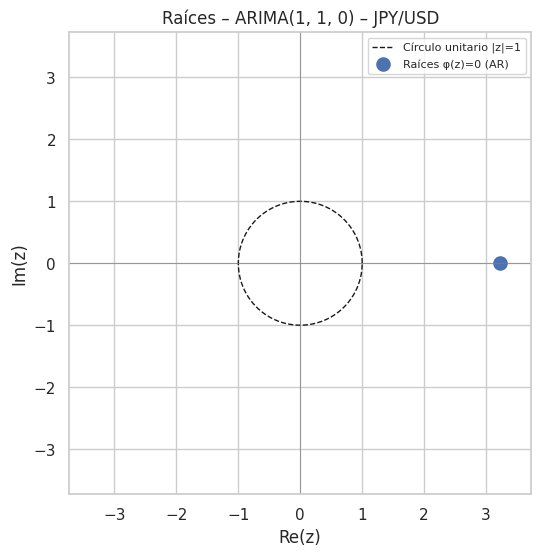

In [7]:
# ==============================================================================
# 4.2 CAUSALIDAD E INVERTIBILIDAD: raíces de φ(z)=0 y θ(z)=0  (|z| > 1)
# ==============================================================================
def analizar_raices(model, nombre):
    # polynomial_ar / polynomial_ma incluyen la parte estacional multiplicada:
    # φ(z)Φ(z^s) = 1 - φ1 z - ...   y   θ(z)Θ(z^s) = 1 + θ1 z + ...
    ar_poly = model.polynomial_ar          # coeficientes en potencias crecientes de z
    ma_poly = model.polynomial_ma
    ar_roots = np.roots(ar_poly[::-1]) if len(np.trim_zeros(ar_poly, 'b')) > 1 else np.array([])
    ma_roots = np.roots(ma_poly[::-1]) if len(np.trim_zeros(ma_poly, 'b')) > 1 else np.array([])

    print(f"=== {nombre} ===")
    print("φ(z) coef.:", np.round(ar_poly, 4))
    print("θ(z) coef.:", np.round(ma_poly, 4))
    for tipo, r, cond in [('AR', ar_roots, 'Causal'), ('MA', ma_roots, 'Invertible')]:
        if len(r) == 0:
            print(f"Raíces {tipo}: no hay (polinomio = 1) -> {cond} trivialmente")
        else:
            print(f"Raíces {tipo}: {np.round(r, 4)} | |z| = {np.round(np.abs(r), 4)}"
                  f" -> {cond}: {np.all(np.abs(r) > 1)}")

    # Redundancia: raíces AR y MA casi iguales se cancelan (factor común)
    if len(ar_roots) and len(ma_roots):
        dist = np.min(np.abs(ar_roots[:, None] - ma_roots[None, :]))
        print(f"Distancia mínima entre raíces AR y MA: {dist:.4f} "
              f"({'posible redundancia' if dist < 0.1 else 'sin redundancia'})")

    # Gráfico en el plano complejo
    fig, ax = plt.subplots(figsize=(6, 6))
    t = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(t), np.sin(t), 'k--', lw=1, label='Círculo unitario |z|=1')
    if len(ar_roots): ax.scatter(ar_roots.real, ar_roots.imag, s=90, marker='o', label='Raíces φ(z)=0 (AR)')
    if len(ma_roots): ax.scatter(ma_roots.real, ma_roots.imag, s=90, marker='x', label='Raíces θ(z)=0 (MA)')
    lim = max(1.5, *(np.abs(np.r_[ar_roots, ma_roots]) + 0.5)) if len(np.r_[ar_roots, ma_roots]) else 1.5
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.axhline(0, color='grey', lw=.5); ax.axvline(0, color='grey', lw=.5)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)'); ax.set_title(f'Raíces – {nombre}'); ax.legend(fontsize=8)
    plt.show()
    return ar_roots, ma_roots

ar_roots_B, ma_roots_B = analizar_raices(model_opt_B, f'ARIMA{orden_B} – JPY/USD')

### 4.3 Diagnóstico de Residuos (Test de Ljung-Box para Ruido Blanco)

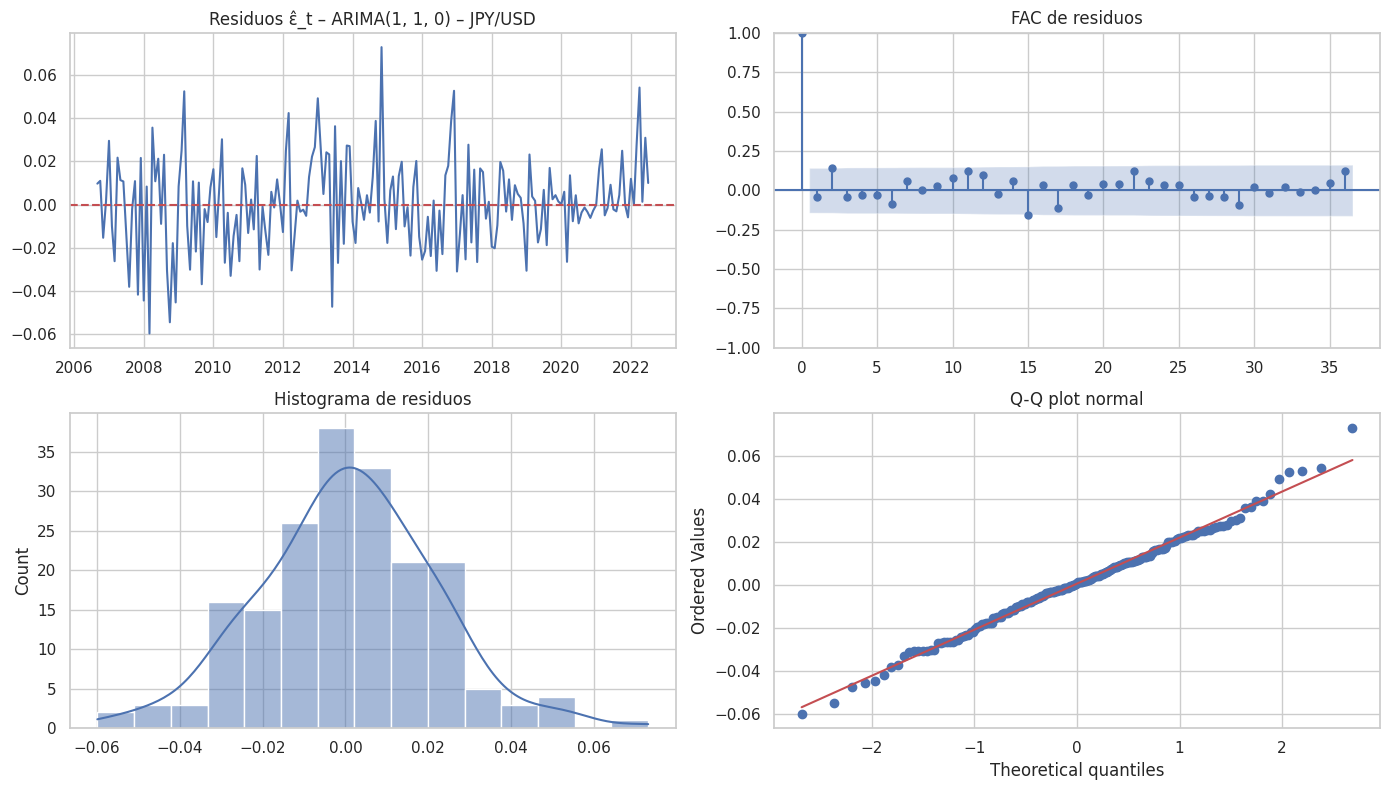

Ljung-Box – ARIMA(1, 1, 0) – JPY/USD (gl ajustados por 1 parámetros ARMA)


,lb_stat,lb_pvalue,¿Ruido Blanco? (p>0.05)
10,8.5721,0.4777,True
15,19.3673,0.1514,True
20,23.1998,0.2287,True
24,27.9625,0.2172,True


Jarque-Bera (normalidad): estadístico = 2.61, p-value = 0.2716


In [11]:
# ==============================================================================
# 4.3 DIAGNÓSTICO DE RESIDUOS: FAC residual + Ljung-Box
# ==============================================================================
from scipy import stats

def diagnostico_residuos(model, nombre, d=1, D=0, s=12):
    burn = d + D*s                               # descartar residuos iniciales de la diferenciación
    residuals = model.resid.iloc[burn:]
    n_par = len(model.params) - 1                # parámetros ARMA (sin σ²)

    fig, ax = plt.subplots(2, 2, figsize=(14, 8))
    ax[0,0].plot(residuals); ax[0,0].axhline(0, color='r', ls='--')
    ax[0,0].set_title(f'Residuos ε̂_t – {nombre}')
    plot_acf(residuals, lags=36, ax=ax[0,1], title='FAC de residuos')
    sns.histplot(residuals, kde=True, ax=ax[1,0]); ax[1,0].set_title('Histograma de residuos')
    stats.probplot(residuals, dist='norm', plot=ax[1,1]); ax[1,1].set_title('Q-Q plot normal')
    plt.tight_layout(); plt.show()

    lb_test = acorr_ljungbox(residuals, lags=[10, 15, 20, 24], model_df=n_par, return_df=True)
    lb_test['¿Ruido Blanco? (p>0.05)'] = lb_test['lb_pvalue'] > 0.05
    print(f"Ljung-Box – {nombre} (gl ajustados por {n_par} parámetros ARMA)")
    display(lb_test.round(4))
    jb = stats.jarque_bera(residuals)
    print(f"Jarque-Bera (normalidad): estadístico = {jb.statistic:.2f}, p-value = {jb.pvalue:.4f}")
    return lb_test

lb_B = diagnostico_residuos(model_opt_B, f'ARIMA{orden_B} – JPY/USD')

### 🧠 Pregunta 3.1:
> 1. ¿El modelo seleccionado cumple formalmente las condiciones de causalidad e invertibilidad?
> 2. Con base en el $p$-valor del test de Ljung-Box ($p > 0.05$), ¿se valida la hipótesis de que los residuos se comportan como Ruido Blanco ($WN$)?  

Causalidad e invertibilidad: el polinomio es φ(z) = 1 − 0.3097z, con raíz z = 3.22, y |z| > 1, así que el modelo es causal.  
Como no tiene parte MA, θ(z) = 1 y es invertible trivialmente. Tampoco hay redundancia, porque no hay raíces AR y MA que puedan cancelarse.  

Ruido blanco: Ljung-box da p = 0.48, 0.15, 0.23 y 0.22 en los rezagos 10, 15, 20 y 24. Todos son >0.05, así que los residuos son ruido blanco.   
Además, Jarque-Bera da p = 0.27, compatible con normalidad.  




## 🎯 5. PARTE IV: Evaluación de Proyecciones y Matriz Comparativa Final

Calculen los errores de pronóstico en el conjunto de prueba (*Test*) mediante las métricas $MAE$, $RMSE$ y $MAPE$.

MATRIZ COMPARATIVA FINAL – JPY/USD (Test: 2022-08 a 2026-08)


,MAE,RMSE,MAPE (%),Ranking
Holt amortiguado,6.350000,7.707000,4.251000,1
Holt-Winters Aditivo,6.544000,7.786000,4.380000,2
Holt-Winters Multiplicativo,6.721000,7.936000,4.489000,3
"SARIMA(1, 1, 0)x(1, 0, 0, 12)",9.030000,10.583000,5.931000,4
"ARIMA(0, 1, 2)",11.265000,12.854000,7.401000,5
"ARIMA(1, 1, 0)",11.571000,13.189000,7.600000,6
Naïve,12.549000,14.265000,8.234000,7
SES,12.549000,14.265000,8.234000,8
Naïve Estacional,29.102000,31.111000,19.407000,9
Promedio Global,44.411000,45.137000,29.697000,10


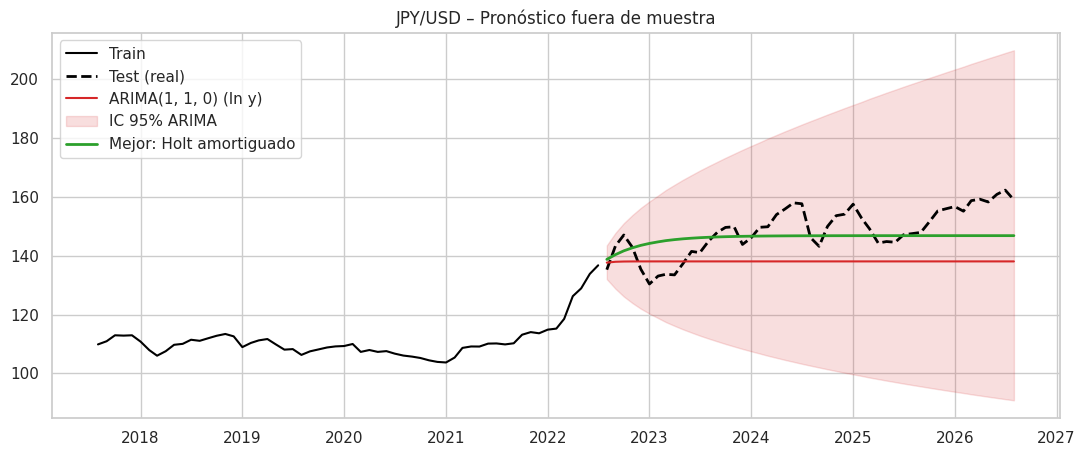

In [13]:
# ==============================================================================
# 5. PRONÓSTICOS OUT-OF-SAMPLE Y MATRIZ COMPARATIVA FINAL
# ==============================================================================
def pronostico_arima(train_log, test, order, seasonal_order):
    m = ARIMA(train_log, order=order, seasonal_order=seasonal_order).fit()
    fc = m.get_forecast(len(test))
    media = np.exp(fc.predicted_mean)                 # regreso a la escala original
    ic = np.exp(fc.conf_int(alpha=0.05))
    media.index = ic.index = test.index
    return media, ic

def matriz_final(test, pred_dict, nombre):
    tabla = pd.DataFrame({k: calcular_metricas(test, v) for k, v in pred_dict.items()}).T
    tabla = tabla.sort_values('RMSE')
    tabla['Ranking'] = range(1, len(tabla) + 1)
    print(f"MATRIZ COMPARATIVA FINAL – {nombre} (Test: {test.index[0]:%Y-%m} a {test.index[-1]:%Y-%m})")
    display(tabla.round(3).style.highlight_min(subset=['MAE', 'RMSE', 'MAPE (%)'], color='lightgreen'))
    return tabla

# Modelo Box-Jenkins seleccionado + dos alternativas del grid para contraste
pred_arima_B = {}
for o, so in [(orden_B, orden_est_B), ((0, 1, 2), (0, 0, 0, 12)), ((1, 1, 0), (1, 0, 0, 12))]:
    etiqueta = f"ARIMA{o}" if so[:3] == (0, 0, 0) else f"SARIMA{o}x{so}"
    pred_arima_B[etiqueta], ic = pronostico_arima(train_B_log, test_B, o, so)
    if o == orden_B and so == orden_est_B:
        ic_B, etiqueta_opt_B = ic, etiqueta

todas_pred_B = {**pred_B, **pred_arima_B}
tabla_final_B = matriz_final(test_B, todas_pred_B, 'JPY/USD')

# Gráfico: mejor modelo vs ARIMA seleccionado con IC 95%
mejor_B = tabla_final_B.index[0]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_B.iloc[-60:], color='black', label='Train')
ax.plot(test_B, color='black', ls='--', lw=2, label='Test (real)')
ax.plot(pred_arima_B[etiqueta_opt_B], color='tab:red', label=etiqueta_opt_B + ' (ln y)')
ax.fill_between(ic_B.index, ic_B.iloc[:, 0], ic_B.iloc[:, 1], color='tab:red', alpha=0.15, label='IC 95% ARIMA')
ax.plot(todas_pred_B[mejor_B], color='tab:green', lw=2, label=f'Mejor: {mejor_B}')
ax.set_title('JPY/USD – Pronóstico fuera de muestra'); ax.legend(); plt.show()

### 🧠 Pregunta 4.1:
> Presenten la tabla comparativa final de proyecciones fuera de muestra. ¿Qué modelo obtuvo el mejor rendimiento global para cada serie? Discutan las razones prácticas y teóricas que explican este resultado.

El mejor modelo es el Holt amortiguado. El test coincide con una depreciación persistente del yen entre 2022 y 2024. Mientras que el ARIMA(1,1,0) converge rápido a un pronóstico plano, casi un random walk.  

Holt lineal falla porque extrapola sin freno la tendencia de apreciación de los últimos meses de train.  

Parsimonia vs. desempeño fuera de muestra: el SARIMA con término estacional pronostica mejor que el ARIMA elegido, pero el BIC lo penalizó.  


## 📚 Referencias Bibliográficas
* Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2016). *Time Series Analysis: Forecasting and Control*. John Wiley & Sons, 5th edition.
* Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: principles and practice*. OTexts, 3rd edition.